In [1]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import requests
import cv2

/Users/S100AHBD/Desktop/CityVision/cityvision/test_cityvision/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/Users/S100AHBD/Desktop/CityVision/cityvision/test_cityvision/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may s

In [2]:
fx = 480.35583204
fy = 437.11894211
cx = 354.90375117
cy = 249.48026187

dis_vec = np.array(
    [-4.09277234e-01, 1.89529196e-01, -2.03433425e-04, -2.01818939e-03, -5.22683299e-02]
)

In [3]:
# Load an image from file
image = Image.open("../assets/test1.jpg")

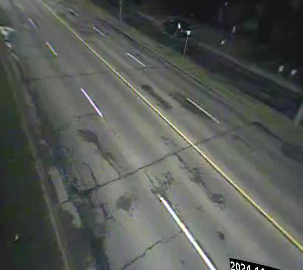

In [4]:
# Convert PIL image to numpy array for OpenCV
img_array = np.array(image)

h, w = img_array.shape[:2]

# Create camera matrix
camera_matrix = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dis_vec, (w, h), 1, (w, h)
)

# undistort
undistorted_img = cv2.undistort(img_array, camera_matrix, dis_vec, None, newcameramtx)

# crop the image
x, y, w, h = roi
undistorted_img = undistorted_img[y : y + h, x : x + w]

undistorted_image = Image.fromarray(undistorted_img)

# Display the undistorted image
undistorted_image

In [5]:
# save the undistorted image
undistorted_image.save("undistorted_test1.jpg")

In [6]:
# save the undistorted image
undistorted_image.save("../undistorted_test1.jpg")
image = undistorted_image

w, h = image.size
holder = Image.new(mode="RGB", size=(w * 2, h))

In [7]:
CHECKPOINT = "depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf"


image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
model = AutoModelForDepthEstimation.from_pretrained(CHECKPOINT)

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    predicted_depth = outputs.predicted_depth

prediction = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic",
    align_corners=False,
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


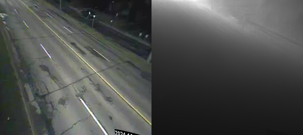

In [8]:
output = prediction.squeeze().cpu().numpy()
formatted = (output * 255 / np.max(output)).astype("uint8")
depth = Image.fromarray(formatted)

holder.paste(depth, (w, 0))
holder.paste(image, (0, 0))
holder.resize((w, h // 2))

In [9]:
output

array([[36.104385 , 36.826214 , 37.477158 , ..., 19.033812 , 19.01794  ,
        19.752123 ],
       [36.177593 , 36.30137  , 36.453396 , ..., 19.268112 , 19.32299  ,
        19.160458 ],
       [35.586357 , 35.345127 , 35.441277 , ..., 19.429943 , 19.394413 ,
        19.347681 ],
       ...,
       [ 4.42382  ,  4.413497 ,  4.4094434, ...,  5.246035 ,  5.296706 ,
         5.300977 ],
       [ 4.41393  ,  4.419136 ,  4.4001675, ...,  5.220938 ,  5.249294 ,
         5.3019314],
       [ 4.4425235,  4.366695 ,  4.359311 , ...,  5.2485075,  5.2734632,
         5.3134193]], dtype=float32)

In [10]:
prediction

tensor([[[[36.1044, 36.8262, 37.4772,  ..., 19.0338, 19.0179, 19.7521],
          [36.1776, 36.3014, 36.4534,  ..., 19.2681, 19.3230, 19.1605],
          [35.5864, 35.3451, 35.4413,  ..., 19.4299, 19.3944, 19.3477],
          ...,
          [ 4.4238,  4.4135,  4.4094,  ...,  5.2460,  5.2967,  5.3010],
          [ 4.4139,  4.4191,  4.4002,  ...,  5.2209,  5.2493,  5.3019],
          [ 4.4425,  4.3667,  4.3593,  ...,  5.2485,  5.2735,  5.3134]]]])

In [11]:
# squezee two first dimension the tensor
prediction = prediction.squeeze(0).squeeze(0)

In [12]:
prediction = prediction.cpu().numpy()
# Normalize the depth values
min_depth = np.min(prediction)
max_depth = np.max(prediction)
prediction_norm = (prediction - min_depth) / (max_depth - min_depth)

In [13]:
import numpy as np


import matplotlib.cm as cm


# Apply a colormap to the depth data
colormap = (
    cm.viridis
)  # You can choose other colormaps like 'plasma', 'inferno', 'magma', 'jet', etc.
depth_colored = colormap(prediction_norm)

# Convert the float values to uint8
depth_colored = (depth_colored[:, :, :3] * 255).astype("uint8")

# Create a new RGB image
depth = Image.fromarray(depth_colored)

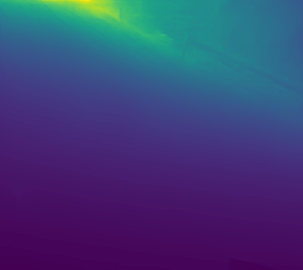

In [14]:
depth

In [15]:
# calculate distance between two points using depth map and camera matrix


def calculate_distance(depth_map, camera_matrix, x1, y1, x2, y2):
    # Get the depth values at the two points
    z1 = depth_map[y1, x1]
    z2 = depth_map[y2, x2]

    # Calculate the 3D coordinates of the two points
    p1 = np.array(
        [
            (x1 - camera_matrix[0, 2]) * z1 / camera_matrix[0, 0],
            (y1 - camera_matrix[1, 2]) * z1 / camera_matrix[1, 1],
            z1,
        ]
    )
    p2 = np.array(
        [
            (x2 - camera_matrix[0, 2]) * z2 / camera_matrix[0, 0],
            (y2 - camera_matrix[1, 2]) * z2 / camera_matrix[1, 1],
            z2,
        ]
    )

    # Calculate the distance between the two points
    distance = np.linalg.norm(p2 - p1)

    return distance

In [16]:
point_to_measure = [
    [[242, 123], [147, 109]],
    [[134, 144], [73, 119]],
    [[242, 123], [134, 144]],
    [[147, 109], [73, 119]],
]

In [17]:
for i, (point1, point2) in enumerate(point_to_measure):
    distance = calculate_distance(
        prediction, camera_matrix, point1[0], point1[1], point2[0], point2[1]
    )
    print(f"The distance between point {i+1} and point {i+2} is {distance:.2f} meters")

The distance between point 1 and point 2 is 2.86 meters
The distance between point 2 and point 3 is 2.34 meters
The distance between point 3 and point 4 is 5.39 meters
The distance between point 4 and point 5 is 3.34 meters
